# Diffusion, Entropy, Escape, and Percolation Fractals

Three-dimensional diffusion, self-avoiding walk scaling, mixing entropy, escape through a hole, and spanning-cluster fractal dimension.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Best-fit slope a = 0.992108
Best-fit intercept b = 3.894069
Estimated diffusion constant D = 0.165351


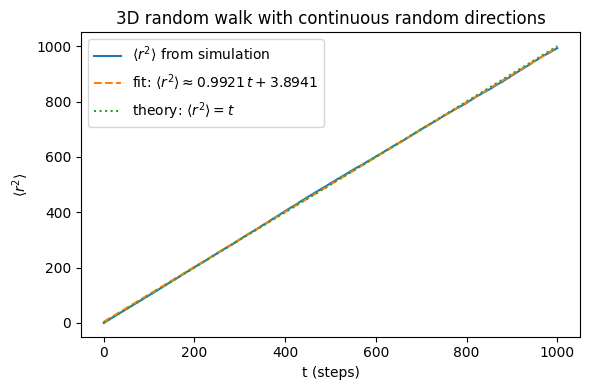

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def random_walk_3d(nsteps: int, nwalks: int, seed: int = 12345):
    rng = np.random.default_rng(seed)

    # positions for all walkers
    x = np.zeros(nwalks)
    y = np.zeros(nwalks)
    z = np.zeros(nwalks)

    mean_r2 = np.zeros(nsteps + 1)

    # initial condition: all walkers at origin
    mean_r2[0] = 0.0

    for n in range(1, nsteps + 1):
        phi = rng.uniform(0.0, 2.0 * np.pi, nwalks)
        u = rng.uniform(-1.0, 1.0, nwalks)   # u = cos(theta)
        s = np.sqrt(1.0 - u**2)

        dx = s * np.cos(phi)
        dy = s * np.sin(phi)
        dz = u

        x += dx
        y += dy
        z += dz

        r2 = x*x + y*y + z*z
        mean_r2[n] = np.mean(r2)

    return np.arange(nsteps + 1), mean_r2


# parameters
nsteps = 1000
nwalks = 20000

t, mean_r2 = random_walk_3d(nsteps=nsteps, nwalks=nwalks, seed=12345)

# fit <r^2> = a t + b, ignoring very early points
fit_start = 50
a, b = np.polyfit(t[fit_start:], mean_r2[fit_start:], 1)

print(f"Best-fit slope a = {a:.6f}")
print(f"Best-fit intercept b = {b:.6f}")

# diffusion constant for one step per unit time: <r^2> = 6 D t
D = a / 6.0
print(f"Estimated diffusion constant D = {D:.6f}")

# plot
plt.figure(figsize=(6, 4))
plt.plot(t, mean_r2, label=r'$\langle r^2 \rangle$ from simulation')
plt.plot(t, a*t + b, '--', label=fr'fit: $\langle r^2 \rangle \approx {a:.4f}\, t + {b:.4f}$')
plt.plot(t, t, ':', label=r'theory: $\langle r^2 \rangle = t$')
plt.xlabel('t (steps)')
plt.ylabel(r'$\langle r^2 \rangle$')
plt.title('3D random walk with continuous random directions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Problem 1 snippet

def random_walk_3d(nsteps: int, nwalks: int, seed: int = 12345):
    rng = np.random.default_rng(seed);
    # positions for all walkers
    x = np.zeros(nwalks);
    y = np.zeros(nwalks);
    z = np.zeros(nwalks);
    mean_r2 = np.zeros(nsteps + 1);
    # initial condition -> all walkers at origin
    mean_r2[0] = 0.0;

    for n in range(1, nsteps + 1):
        phi = rng.uniform(0.0, 2.0 * np.pi, nwalks);
        u = rng.uniform(-1.0, 1.0, nwalks);   # u = cos(theta)
        s = np.sqrt(1.0 - u**2);

        dx = s * np.cos(phi);
        dy = s * np.sin(phi);
        dz = u;

        x += dx;
        y += dy;
        z += dz;

        r2 = x*x + y*y + z*z;
        mean_r2[n] = np.mean(r2);

    return np.arange(nsteps + 1), mean_r2;

2D results
Estimated nu (growing SAW) = 0.637607
Fit exponent for <r^2> = 1.275213
Fraction surviving to n=50: 0.580110

3D results
Estimated nu (growing SAW) = 0.543407
Fit exponent for <r^2> = 1.086814
Fraction surviving to n=50: 0.997610


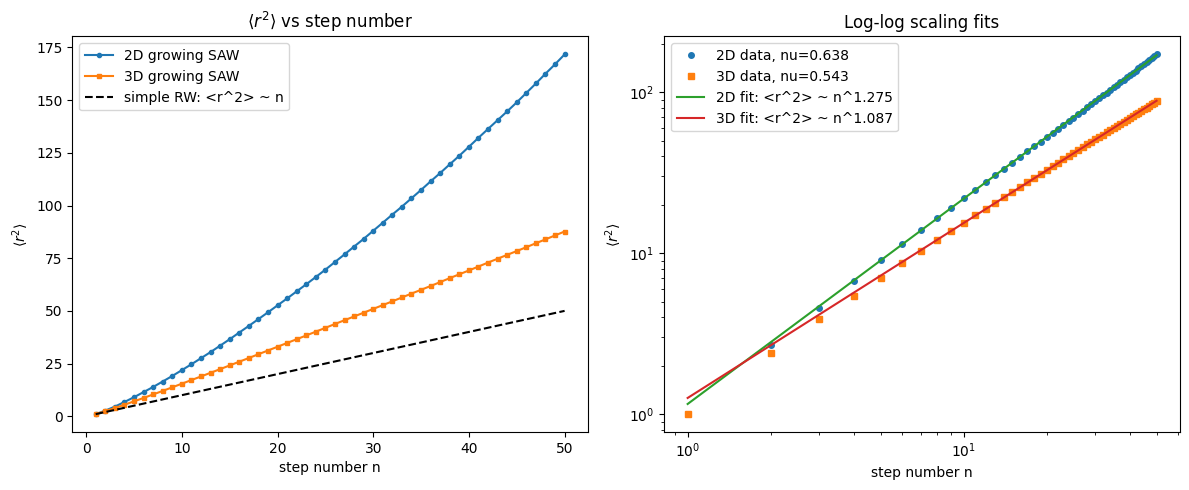

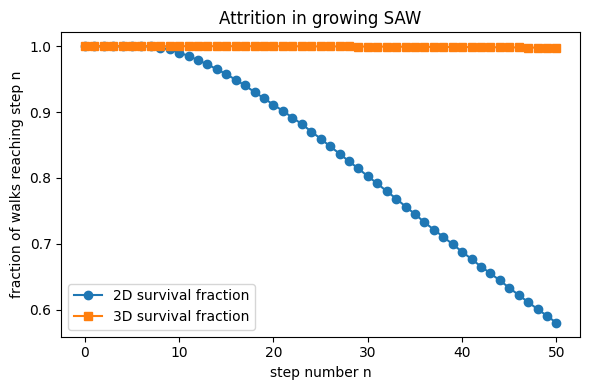

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def grow_saw(dim, nsteps, rng):
    """
    Grow one self-avoiding walk on a hypercubic lattice in 2D or 3D.
    Returns:
        success (bool), positions (array of shape (m+1, dim))
    If trapped before reaching nsteps, success=False and positions contains
    the partial walk up to the trap.
    """
    if dim == 2:
        directions = np.array([
            [1, 0], [-1, 0], [0, 1], [0, -1]
        ], dtype=int)
    elif dim == 3:
        directions = np.array([
            [1, 0, 0], [-1, 0, 0],
            [0, 1, 0], [0, -1, 0],
            [0, 0, 1], [0, 0, -1]
        ], dtype=int)
    else:
        raise ValueError("dim must be 2 or 3")

    pos = np.zeros(dim, dtype=int)
    visited = {tuple(pos)}
    positions = [pos.copy()]

    for _ in range(nsteps):
        candidates = []
        for d in directions:
            new_pos = pos + d
            if tuple(new_pos) not in visited:
                candidates.append(new_pos)

        if not candidates:
            return False, np.array(positions, dtype=int)

        pos = candidates[rng.integers(len(candidates))]
        visited.add(tuple(pos))
        positions.append(pos.copy())

    return True, np.array(positions, dtype=int)


def simulate_growing_saw(dim, nsteps, ntrials, seed=12345):
    """
    Simulate many SAW attempts.
    Returns:
        mean_r2_survivors[k] = average r^2 at step k over walks that reached step k
        survivors[k] = number of walks that reached step k
        success_fraction_full = fraction that reached nsteps
    """
    rng = np.random.default_rng(seed)

    sum_r2 = np.zeros(nsteps + 1, dtype=float)
    survivors = np.zeros(nsteps + 1, dtype=int)

    for _ in range(ntrials):
        success, positions = grow_saw(dim, nsteps, rng)
        r2 = np.sum(positions**2, axis=1)
        m = len(r2) - 1  # highest completed step

        sum_r2[:m+1] += r2
        survivors[:m+1] += 1

    mean_r2 = np.full(nsteps + 1, np.nan)
    mask = survivors > 0
    mean_r2[mask] = sum_r2[mask] / survivors[mask]

    success_fraction_full = survivors[nsteps] / ntrials
    return mean_r2, survivors, success_fraction_full


def fit_nu(mean_r2, fit_start=5):
    """
    Fit <r^2> ~ C n^(2 nu) on log-log axes.
    Returns nu, slope, intercept.
    """
    n = np.arange(len(mean_r2))
    mask = (n >= fit_start) & np.isfinite(mean_r2) & (mean_r2 > 0)

    x = np.log(n[mask])
    y = np.log(mean_r2[mask])

    slope, intercept = np.polyfit(x, y, 1)
    nu = slope / 2.0
    return nu, slope, intercept


# =========================
# Parameters
# =========================
nsteps_2d = 50
nsteps_3d = 50

# For 2D, use a larger sample so the estimate gets closer to 3/4
ntrials_2d = 100000
ntrials_3d = 100000

# =========================
# 2D simulation
# =========================
mean_r2_2d, surv_2d, frac2d = simulate_growing_saw(
    dim=2, nsteps=nsteps_2d, ntrials=ntrials_2d, seed=12345
)
nu2d, slope2d, b2d = fit_nu(mean_r2_2d, fit_start=5)

# =========================
# 3D simulation
# =========================
mean_r2_3d, surv_3d, frac3d = simulate_growing_saw(
    dim=3, nsteps=nsteps_3d, ntrials=ntrials_3d, seed=67890
)
nu3d, slope3d, b3d = fit_nu(mean_r2_3d, fit_start=5)

print("2D results")
print(f"Estimated nu (growing SAW) = {nu2d:.6f}")
print(f"Fit exponent for <r^2> = {slope2d:.6f}")
print(f"Fraction surviving to n={nsteps_2d}: {frac2d:.6f}")

print("\n3D results")
print(f"Estimated nu (growing SAW) = {nu3d:.6f}")
print(f"Fit exponent for <r^2> = {slope3d:.6f}")
print(f"Fraction surviving to n={nsteps_3d}: {frac3d:.6f}")

# =========================
# Plots
# =========================
n2 = np.arange(1, nsteps_2d + 1)
n3 = np.arange(1, nsteps_3d + 1)

plt.figure(figsize=(12, 5))

# Left: <r^2> vs n
plt.subplot(1, 2, 1)
plt.plot(n2, mean_r2_2d[1:], 'o-', markersize=3, label='2D growing SAW')
plt.plot(n3, mean_r2_3d[1:], 's-', markersize=3, label='3D growing SAW')
plt.plot(n2, n2, 'k--', label='simple RW: <r^2> ~ n')
plt.xlabel('step number n')
plt.ylabel(r'$\langle r^2 \rangle$')
plt.title(r'$\langle r^2 \rangle$ vs step number')
plt.legend()

# Right: log-log fit
plt.subplot(1, 2, 2)
plt.loglog(n2, mean_r2_2d[1:], 'o', markersize=4, label=f'2D data, nu={nu2d:.3f}')
plt.loglog(n3, mean_r2_3d[1:], 's', markersize=4, label=f'3D data, nu={nu3d:.3f}')

fit2 = np.exp(b2d) * n2**slope2d
fit3 = np.exp(b3d) * n3**slope3d
plt.loglog(n2, fit2, '-', label=f'2D fit: <r^2> ~ n^{slope2d:.3f}')
plt.loglog(n3, fit3, '-', label=f'3D fit: <r^2> ~ n^{slope3d:.3f}')

plt.xlabel('step number n')
plt.ylabel(r'$\langle r^2 \rangle$')
plt.title('Log-log scaling fits')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Problem 2 Snippets

def grow_saw(dim, nsteps, rng):
    if dim == 2:
        directions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]], dtype = int);
    elif dim == 3:
        directions = np.array([[1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, 1], [0, 0, -1]], dtype = int);
    else:
        raise ValueError("dim must be 2 or 3");

    pos = np.zeros(dim, dtype = int);
    visited = {tuple(pos)};
    positions = [pos.copy()];

    for _ in range(nsteps):
        candidates = [];
        for d in directions:
            new_pos = pos + d;
            if tuple(new_pos) not in visited:
                candidates.append(new_pos);

        if not candidates:
            return False, np.array(positions, dtype = int);

        pos = candidates[rng.integers(len(candidates))];
        visited.add(tuple(pos));
        positions.append(pos.copy());

    return True, np.array(positions, dtype = int);


def simulate_growing_saw(dim, nsteps, ntrials, seed = 12345):
    rng = np.random.default_rng(seed);
    sum_r2 = np.zeros(nsteps + 1, dtype = float);
    survivors = np.zeros(nsteps + 1, dtype = int);

    for _ in range(ntrials):
        success, positions = grow_saw(dim, nsteps, rng);
        r2 = np.sum(positions**2, axis = 1);
        m = len(r2) - 1;  # highest completed step
        sum_r2[:m+1] += r2;
        survivors[:m+1] += 1;

    mean_r2 = np.full(nsteps + 1, np.nan);
    mask = survivors > 0;
    mean_r2[mask] = sum_r2[mask] / survivors[mask];
    success_fraction_full = survivors[nsteps] / ntrials;

    return mean_r2, survivors, success_fraction_full;


def fit_nu(mean_r2, fit_start = 5):
    n = np.arange(len(mean_r2));
    mask = (n >= fit_start) & np.isfinite(mean_r2) & (mean_r2 > 0);
    x = np.log(n[mask]);
    y = np.log(mean_r2[mask]);
    slope, intercept = np.polyfit(x, y, 1);
    nu = slope / 2.0;

    return nu, slope, intercept;

Initial entropy S(0) = 1.386294
Final entropy S(final) = 4.090632
Theoretical maximum Smax = ln(64) = 4.158883


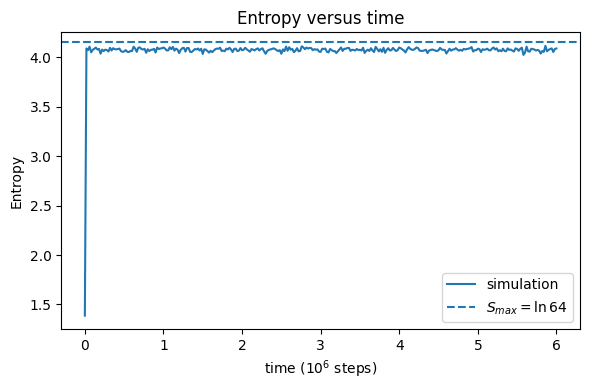

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_walkers_square(nrw_side=20):
    """
    Put walkers in a compact square centered at the origin.
    nrw_side=20 gives 20x20 = 400 walkers.
    """
    coords = []
    half = nrw_side // 2
    for i in range(-half, half):
        for j in range(-half, half):
            coords.append([i, j])
    return np.array(coords, dtype=int)

def step_walkers_reflecting(pos, L, rng):
    """
    One random-walk step for every walker on a square box [-L, L] x [-L, L].
    Reflecting boundary in the same spirit as the sample code:
    if a walker is at boundary and tries to move outward, force it inward.
    """
    nrw = pos.shape[0]

    choose_axis = rng.integers(0, 2, size=nrw)      # 0 for x, 1 for y
    choose_sign = rng.choice([-1, 1], size=nrw)

    for i in range(nrw):
        ax = choose_axis[i]
        sgn = choose_sign[i]

        # normal move if not trying to step outside boundary
        if abs(pos[i, ax]) < L:
            pos[i, ax] += sgn
        else:
            # at boundary: only move back inward
            pos[i, ax] -= np.sign(pos[i, ax])

def coarse_entropy(pos, L, ngrids):
    """
    Compute coarse-grained entropy S = -sum p_ij ln p_ij
    using an ngrids x ngrids coarse grid over [-L, L] x [-L, L].
    """
    edges = np.linspace(-L, L, ngrids + 1)
    H, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=[edges, edges])

    p = H / H.sum()
    p_nonzero = p[p > 0]
    S = -np.sum(p_nonzero * np.log(p_nonzero))
    return S

def simulate_entropy(
    total_steps=6_000_000,
    sample_every=20_000,
    L=100,
    ngrids=8,
    nrw_side=20,
    seed=12345
):
    """
    Simulate cream-in-coffee mixing and compute entropy vs time.
    """
    rng = np.random.default_rng(seed)
    pos = initialize_walkers_square(nrw_side=nrw_side)  # 20x20 -> 400 walkers

    times = [0]
    entropies = [coarse_entropy(pos, L=L, ngrids=ngrids)]

    n_samples = total_steps // sample_every
    for k in range(1, n_samples + 1):
        for _ in range(sample_every):
            step_walkers_reflecting(pos, L=L, rng=rng)

        times.append(k * sample_every)
        entropies.append(coarse_entropy(pos, L=L, ngrids=ngrids))

    return np.array(times), np.array(entropies), pos


# Parameters chosen to match the figure style reasonably well
total_steps = 6000000
sample_every = 20000
L = 100
ngrids = 8
nrw_side = 20   # 400 walkers total

times, entropies, final_pos = simulate_entropy(
    total_steps=total_steps,
    sample_every=sample_every,
    L=L,
    ngrids=ngrids,
    nrw_side=nrw_side,
    seed=12345
)

Smax = np.log(ngrids * ngrids)

print(f"Initial entropy S(0) = {entropies[0]:.6f}")
print(f"Final entropy S(final) = {entropies[-1]:.6f}")
print(f"Theoretical maximum Smax = ln({ngrids*ngrids}) = {Smax:.6f}")

plt.figure(figsize=(6,4))
plt.plot(times / 1e6, entropies, label='simulation')
plt.axhline(Smax, linestyle='--', label=fr'$S_{{max}}=\ln {ngrids*ngrids}$')
plt.xlabel(r'time ($10^6$ steps)')
plt.ylabel('Entropy')
plt.title('Entropy versus time')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Problem 3 Snippets

# Put walkers in a compact square centered at the origin.
def initialize_walkers_square(nrw_side = 20):
    coords = [];
    half = nrw_side // 2;
    for i in range(-half, half):
        for j in range(-half, half):
            coords.append([i, j]);
    return np.array(coords, dtype = int)

# One random-walk step for every walker on a square box
def step_walkers_reflecting(pos, L, rng):
    nrw = pos.shape[0];
    choose_axis = rng.integers(0, 2, size = nrw);      # 0 for x, 1 for y
    choose_sign = rng.choice([-1, 1], size = nrw);

    for i in range(nrw):
        ax = choose_axis[i];
        sgn = choose_sign[i];
        # normal move if not trying to step outside boundary
        if abs(pos[i, ax]) < L:
            pos[i, ax] += sgn;
        else:
            pos[i, ax] -= np.sign(pos[i, ax]);   # at boundary: only move back inward

# Compute coarse-grained entropy S = -sum p_ij ln p_ij using an ngrids x ngrids coarse grid over [-L, L] x [-L, L]
def coarse_entropy(pos, L, ngrids):
    edges = np.linspace(-L, L, ngrids + 1);
    H, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins = [edges, edges]);
    p = H / H.sum();
    p_nonzero = p[p > 0];
    S = -np.sum(p_nonzero * np.log(p_nonzero));
    return S;

# Simulate cream-in-coffee mixing and compute entropy vs time
def simulate_entropy(total_steps = 6_000_000, sample_every = 20_000, L = 100, ngrids = 8, nrw_side = 20, seed = 12345):
    rng = np.random.default_rng(seed);
    pos = initialize_walkers_square(nrw_side = nrw_side);  # 20x20 -> 400 walkers
    times = [0];
    entropies = [coarse_entropy(pos, L = L, ngrids = ngrids)];
    n_samples = total_steps // sample_every

    for k in range(1, n_samples + 1):
        for _ in range(sample_every):
            step_walkers_reflecting(pos, L = L, rng = rng);

        times.append(k * sample_every)
        entropies.append(coarse_entropy(pos, L = L, ngrids = ngrids));

    return np.array(times), np.array(entropies), pos;


Initial particle number N0 = 400
Final particle number = 0
Fit slope for ln N vs t = -9.651387e-05
Estimated tau = 10361.205


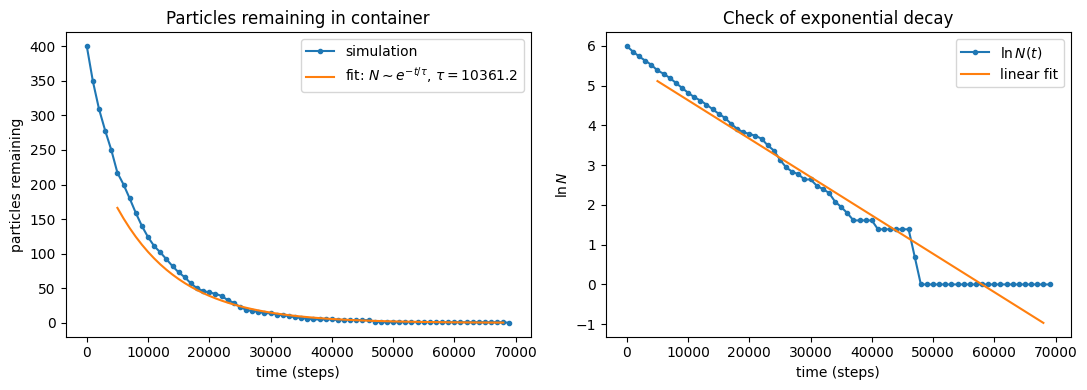

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_walkers_square(nrw_side=20):
    """
    Place walkers in a compact square centered at the origin.
    nrw_side=20 gives 400 walkers.
    """
    coords = []
    half = nrw_side // 2
    for i in range(-half, half):
        for j in range(-half, half):
            coords.append([i, j])
    return np.array(coords, dtype=int)

def step_with_hole(pos, L, hole_len, rng):
    """
    One vectorized random-walk step for all surviving walkers.

    Box is [-L, L] x [-L, L].
    Reflecting walls everywhere except for a hole in the right wall x = L.
    If a particle at x=L steps outward through y in the hole interval, it escapes.

    Hole is centered on the right wall and has total length hole_len.
    """
    if len(pos) == 0:
        return pos

    n = len(pos)
    axis = rng.integers(0, 2, size=n)          # 0 -> x, 1 -> y
    sign = rng.choice(np.array([-1, 1]), size=n)

    rows = np.arange(n)

    # Proposed moves
    new_pos = pos.copy()
    new_pos[rows, axis] += sign

    # Hole on right wall x=L, centered in y
    ymin = -hole_len // 2
    ymax = hole_len // 2

    # Detect escape attempts:
    # walker currently at right wall x=L, tries to step outward in +x,
    # and y-coordinate lies within hole opening
    escape = (
        (axis == 0) &
        (sign == 1) &
        (pos[:, 0] == L) &
        (pos[:, 1] >= ymin) &
        (pos[:, 1] < ymax)
    )

    # Remove escaped walkers
    keep = ~escape
    pos = pos[keep]
    new_pos = new_pos[keep]

    if len(pos) == 0:
        return pos

    # Reflecting walls for all non-escape boundary crossings
    new_pos[:, 0] = np.where(new_pos[:, 0] > L, L - 1, new_pos[:, 0])
    new_pos[:, 0] = np.where(new_pos[:, 0] < -L, -L + 1, new_pos[:, 0])
    new_pos[:, 1] = np.where(new_pos[:, 1] > L, L - 1, new_pos[:, 1])
    new_pos[:, 1] = np.where(new_pos[:, 1] < -L, -L + 1, new_pos[:, 1])

    return new_pos

def simulate_escape(
    total_steps=200000,
    sample_every=1000,
    L=25,             # 50x50 style container
    hole_len=10,
    nrw_side=20,      # 400 particles
    seed=12345
):
    rng = np.random.default_rng(seed)
    pos = initialize_walkers_square(nrw_side=nrw_side)

    times = [0]
    counts = [len(pos)]

    nsamples = total_steps // sample_every

    for k in range(1, nsamples + 1):
        for _ in range(sample_every):
            pos = step_with_hole(pos, L=L, hole_len=hole_len, rng=rng)
            if len(pos) == 0:
                break

        times.append(k * sample_every)
        counts.append(len(pos))

        if len(pos) == 0:
            break

    return np.array(times), np.array(counts)

def fit_tau(times, counts, fit_start_index=5):
    """
    Fit N(t) = N0 exp(-t/tau) by fitting ln N = a + b t.
    Then tau = -1/b.
    """
    mask = (counts > 0)
    times = times[mask]
    counts = counts[mask]

    # Ignore earliest points if desired
    times_fit = times[fit_start_index:]
    counts_fit = counts[fit_start_index:]

    y = np.log(counts_fit)
    b, a = np.polyfit(times_fit, y, 1)   # y = b t + a
    tau = -1 / b

    return tau, a, b, times_fit, counts_fit

# ---------------------------
# Run
# ---------------------------
times, counts = simulate_escape(
    total_steps=200000,
    sample_every=1000,
    L=25,
    hole_len=10,
    nrw_side=20,
    seed=12345
)

tau, a, b, times_fit, counts_fit = fit_tau(times, counts, fit_start_index=5)

print(f"Initial particle number N0 = {counts[0]}")
print(f"Final particle number = {counts[-1]}")
print(f"Fit slope for ln N vs t = {b:.6e}")
print(f"Estimated tau = {tau:.3f}")

# Fitted curve
Nfit = np.exp(a + b * times_fit)

plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(times, counts, 'o-', ms=3, label='simulation')
plt.plot(times_fit, Nfit, '-', label=fr'fit: $N \sim e^{{-t/\tau}}$, $\tau={tau:.1f}$')
plt.xlabel('time (steps)')
plt.ylabel('particles remaining')
plt.title('Particles remaining in container')
plt.legend()

plt.subplot(1,2,2)
plt.plot(times, np.log(np.maximum(counts, 1)), 'o-', ms=3, label=r'$\ln N(t)$')
plt.plot(times_fit, a + b * times_fit, '-', label='linear fit')
plt.xlabel('time (steps)')
plt.ylabel(r'$\ln N$')
plt.title(r'Check of exponential decay')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Problem 4 Snippet

# Place walkers in a compact square centered at the origin
def initialize_walkers_square(nrw_side = 20):
    coords = [];
    half = nrw_side // 2;
    for i in range(-half, half):
        for j in range(-half, half):
            coords.append([i, j]);
    return np.array(coords, dtype = int);

# One vectorized random-walk step for all surviving walkers. Reflecting walls everywhere except for a hole in the right wall.
def step_with_hole(pos, L, hole_len, rng):
    if len(pos) == 0:
        return pos;
    n = len(pos);
    axis = rng.integers(0, 2, size = n);          # 0 -> x, 1 -> y
    sign = rng.choice(np.array([-1, 1]), size = n);
    rows = np.arange(n);

    # Proposed moves
    new_pos = pos.copy();
    new_pos[rows, axis] += sign;
    # Hole on right wall
    ymin = -hole_len // 2;
    ymax = hole_len // 2;
    escape = ((axis == 0) & (sign == 1) & (pos[:, 0] == L) & (pos[:, 1] >= ymin) & (pos[:, 1] < ymax));
    # Remove escaped walkers
    keep = ~escape;
    pos = pos[keep];
    new_pos = new_pos[keep];

    if len(pos) == 0:
        return pos;
    # Reflecting walls for all non-escape boundary crossings
    new_pos[:, 0] = np.where(new_pos[:, 0] > L, L - 1, new_pos[:, 0])
    new_pos[:, 0] = np.where(new_pos[:, 0] < -L, -L + 1, new_pos[:, 0])
    new_pos[:, 1] = np.where(new_pos[:, 1] > L, L - 1, new_pos[:, 1])
    new_pos[:, 1] = np.where(new_pos[:, 1] < -L, -L + 1, new_pos[:, 1])

    return new_pos;

def simulate_escape(total_steps = 200000, sample_every = 1000, L = 25, hole_len = 10, nrw_side = 20, seed = 12345):
    rng = np.random.default_rng(seed);
    pos = initialize_walkers_square(nrw_side = nrw_side);
    times = [0];
    counts = [len(pos)];
    nsamples = total_steps // sample_every;

    for k in range(1, nsamples + 1):
        for _ in range(sample_every):
            pos = step_with_hole(pos, L = L, hole_len = hole_len, rng = rng);
            if len(pos) == 0:
                break;
        times.append(k * sample_every);
        counts.append(len(pos));
        if len(pos) == 0:
            break;

    return np.array(times), np.array(counts);

# Fit N(t) = N0 exp(-t/tau) by fitting ln N = a + b t and then tau = -1/b
def fit_tau(times, counts, fit_start_index = 5):
    mask = (counts > 0);
    times = times[mask];
    counts = counts[mask];
    # Ignore earliest points if desired
    times_fit = times[fit_start_index:];
    counts_fit = counts[fit_start_index:];

    y = np.log(counts_fit);
    b, a = np.polyfit(times_fit, y, 1);   # y = b t + a
    tau = -1 / b;

    return tau, a, b, times_fit, counts_fit;


Lattice sizes: [ 16  24  32  48  64  96 128]
Mean spanning masses: [ 102.4   221.05  366.7   793.5  1271.65 2925.   5220.15]
Estimated fractal dimension d_f = 1.876247


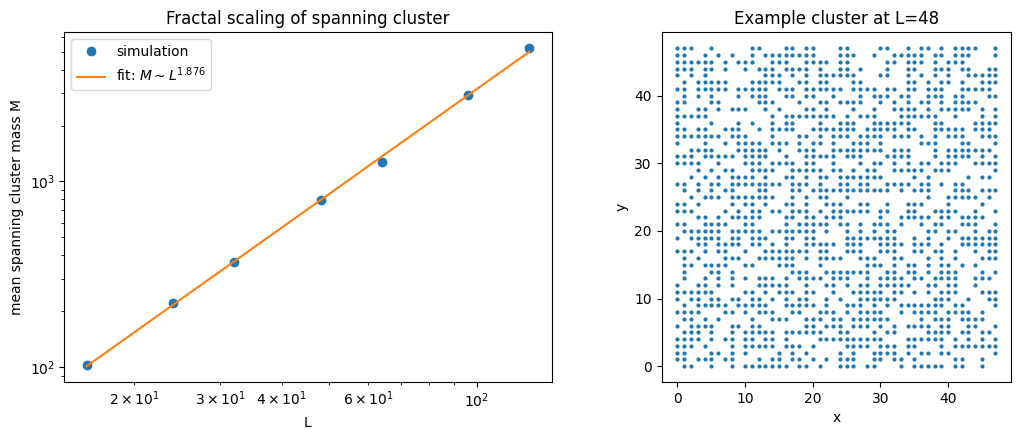

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

def find_clusters_and_spanning(lattice):
    """
    Find all occupied clusters on a 2D square lattice using BFS.
    Returns:
        spanning_masses: list of masses of spanning clusters
        labeled: cluster labels array
    """
    L = lattice.shape[0]
    labeled = np.zeros((L, L), dtype=int)
    cluster_id = 0
    spanning_masses = []

    # nearest neighbors
    nbrs = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    for i in range(L):
        for j in range(L):
            if lattice[i, j] and labeled[i, j] == 0:
                cluster_id += 1
                q = deque()
                q.append((i, j))
                labeled[i, j] = cluster_id

                mass = 0
                touches_left = False
                touches_right = False
                touches_top = False
                touches_bottom = False

                while q:
                    x, y = q.popleft()
                    mass += 1

                    if y == 0:
                        touches_left = True
                    if y == L - 1:
                        touches_right = True
                    if x == 0:
                        touches_top = True
                    if x == L - 1:
                        touches_bottom = True

                    for dx, dy in nbrs:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < L and 0 <= ny < L:
                            if lattice[nx, ny] and labeled[nx, ny] == 0:
                                labeled[nx, ny] = cluster_id
                                q.append((nx, ny))

                if (touches_left and touches_right) or (touches_top and touches_bottom):
                    spanning_masses.append(mass)

    return spanning_masses, labeled


def generate_spanning_cluster(L, p, rng, max_tries=1000):
    """
    Keep generating lattices until a spanning cluster is found.
    Returns:
        lattice, labeled_clusters, chosen_spanning_mass
    """
    for _ in range(max_tries):
        lattice = rng.random((L, L)) < p
        spanning_masses, labeled = find_clusters_and_spanning(lattice)
        if spanning_masses:
            # choose the largest spanning cluster if more than one exists
            return lattice, labeled, max(spanning_masses)
    return None, None, None


def estimate_df(
    sizes=(16, 24, 32, 48, 64, 96, 128),
    p=0.592746,
    nsamples=20,
    seed=12345
):
    rng = np.random.default_rng(seed)

    mean_masses = []
    std_masses = []
    good_sizes = []

    saved_example = None  # save one example cluster near the middle size

    for L in sizes:
        masses = []

        for _ in range(nsamples):
            lattice, labeled, mass = generate_spanning_cluster(L, p, rng)
            if mass is not None:
                masses.append(mass)

                # save one example spanning cluster for plotting
                if saved_example is None and L == sizes[len(sizes)//2]:
                    saved_example = (L, lattice.copy(), labeled.copy(), mass)

        if len(masses) > 0:
            good_sizes.append(L)
            mean_masses.append(np.mean(masses))
            std_masses.append(np.std(masses, ddof=1) if len(masses) > 1 else 0.0)

    good_sizes = np.array(good_sizes, dtype=float)
    mean_masses = np.array(mean_masses, dtype=float)
    std_masses = np.array(std_masses, dtype=float)

    # log-log fit: M ~ L^df
    coeffs = np.polyfit(np.log(good_sizes), np.log(mean_masses), 1)
    df = coeffs[0]
    intercept = coeffs[1]

    return good_sizes, mean_masses, std_masses, df, intercept, saved_example


# ----------------------------
# Run
# ----------------------------
sizes, mean_masses, std_masses, df, intercept, saved_example = estimate_df(
    sizes=(16, 24, 32, 48, 64, 96, 128),
    p=0.592746,
    nsamples=20,
    seed=12345
)

print("Lattice sizes:", sizes.astype(int))
print("Mean spanning masses:", mean_masses)
print(f"Estimated fractal dimension d_f = {df:.6f}")

# fit curve
Lfit = np.linspace(min(sizes), max(sizes), 300)
Mfit = np.exp(intercept) * Lfit**df

plt.figure(figsize=(11, 4.5))

# Left panel: log-log scaling
plt.subplot(1, 2, 1)
plt.loglog(sizes, mean_masses, 'o', label='simulation')
plt.loglog(Lfit, Mfit, '-', label=fr'fit: $M \sim L^{{{df:.3f}}}$')
plt.xlabel('L')
plt.ylabel('mean spanning cluster mass M')
plt.title('Fractal scaling of spanning cluster')
plt.legend()

# Right panel: one example spanning cluster
if saved_example is not None:
    L0, lattice0, labeled0, mass0 = saved_example

    # identify largest spanning cluster label
    spanning_masses, _ = find_clusters_and_spanning(lattice0)

    # just plot all occupied sites if we don't isolate label explicitly
    plt.subplot(1, 2, 2)
    x, y = np.where(lattice0)
    plt.scatter(y, L0 - 1 - x, s=4)
    plt.gca().set_aspect('equal')
    plt.title(f'Example cluster at L={L0}')
    plt.xlabel('x')
    plt.ylabel('y')

plt.tight_layout()
plt.show()

In [ ]:
# Find all occupied clusters on a 2D square lattice using BFS
def find_clusters_and_spanning(lattice):
    L = lattice.shape[0];
    labeled = np.zeros((L, L), dtype = int);
    cluster_id = 0;
    spanning_masses = [];
    nbrs = [(1, 0), (-1, 0), (0, 1), (0, -1)];

    for i in range(L):
        for j in range(L):
            if lattice[i, j] and labeled[i, j] == 0:
                cluster_id += 1;
                q = deque();
                q.append((i, j));
                labeled[i, j] = cluster_id;
                mass = 0;
                touches_left = False; touches_right = False;  touches_top = False;  touches_bottom = False;
                while q:
                    x, y = q.popleft();
                    mass += 1;
                    if y == 0:  touches_left = True;
                    if y == L - 1:  touches_right = True;
                    if x == 0:  touches_top = True;
                    if x == L - 1:  touches_bottom = True;
                    for dx, dy in nbrs:
                        nx, ny = x + dx, y + dy;
                        if 0 <= nx < L and 0 <= ny < L:
                            if lattice[nx, ny] and labeled[nx, ny] == 0:
                                labeled[nx, ny] = cluster_id;
                                q.append((nx, ny));
                if (touches_left and touches_right) or (touches_top and touches_bottom):
                    spanning_masses.append(mass);

    return spanning_masses, labeled;

# Keep generating lattices until a spanning cluster is found.
def generate_spanning_cluster(L, p, rng, max_tries = 1000):
  for _ in range(max_tries):
        lattice = rng.random((L, L)) < p;
        spanning_masses, labeled = find_clusters_and_spanning(lattice);
        if spanning_masses:
            return lattice, labeled, max(spanning_masses); # choose the largest spanning cluster if more than one exists
  return None, None, None;


def estimate_df(sizes = (16, 24, 32, 48, 64, 96, 128), p = 0.592746, nsamples = 20, seed = 12345):
    rng = np.random.default_rng(seed);
    mean_masses = [];
    std_masses = [];
    good_sizes = [];
    saved_example = None;  # save one example cluster near the middle size

    for L in sizes:
        masses = [];
        for _ in range(nsamples):
            lattice, labeled, mass = generate_spanning_cluster(L, p, rng);
            if mass is not None:
                masses.append(mass);
                # save one example spanning cluster for plotting
                if saved_example is None and L == sizes[len(sizes)//2]:
                    saved_example = (L, lattice.copy(), labeled.copy(), mass);

        if len(masses) > 0:
            good_sizes.append(L);
            mean_masses.append(np.mean(masses));
            std_masses.append(np.std(masses, ddof = 1) if len(masses) > 1 else 0.0);

    good_sizes = np.array(good_sizes, dtype = float);
    mean_masses = np.array(mean_masses, dtype = float);
    std_masses = np.array(std_masses, dtype = float);
    # log-log fit: M ~ L^df
    coeffs = np.polyfit(np.log(good_sizes), np.log(mean_masses), 1);
    df = coeffs[0];
    intercept = coeffs[1];

    return good_sizes, mean_masses, std_masses, df, intercept, saved_example;
